<a href="https://colab.research.google.com/github/wgcv/gesture-mlai-assessment/blob/main/submission/gesture_mlai_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gesture — AI/ML Engineer Assessment

## Data analysis

### Download CSV

In [63]:
import requests

urls = [
    "https://raw.githubusercontent.com/wgcv/gesture-mlai-assessment/refs/heads/main/data/user_events.csv",
    "https://raw.githubusercontent.com/wgcv/gesture-mlai-assessment/refs/heads/main/data/product_catalog.csv"
]

for url in urls:
    filename = url.split("/")[-1]

    try:
        r = requests.get(url)
        r.raise_for_status()

        with open(filename, "wb") as f:
            f.write(r.content)

        print(f"Downloaded: {filename}")

    except requests.exceptions.RequestException as e:
        print(f"Failed: {url} -> {e}")

Downloaded: user_events.csv
Downloaded: product_catalog.csv


### Load user_events

In [64]:
import pandas as pd

df_events = pd.read_csv("user_events.csv")

df_events.head()


,event_id,user_id,event_type,timestamp,sku_id,price_usd,recipient_id,platform,user_type
0,evt_0018094,usr_0556,app_open,2026-01-01 09:57:00,NaN,NaN,NaN,ios,b2b
1,evt_0009755,usr_0302,app_open,2026-02-18 08:57:00,NaN,NaN,NaN,android,b2b
2,evt_0021240,usr_0649,app_open,2025-11-30 22:03:00,NaN,NaN,NaN,ios,b2c
3,evt_0006725,usr_0209,product_view,2026-03-28 15:26:00,SKU029,82.0,NaN,ios,b2c
4,evt_0008882,usr_0285,app_open,2026-03-29 07:03:00,NaN,NaN,NaN,ios,b2c


### Load product_catalog

In [65]:
import pandas as pd

df_products = pd.read_csv("product_catalog.csv")

df_products.head()


,sku_id,title,category,price_usd,description
0,SKU001,Luxury Candle Set,candle,65,Hand-poured soy wax candles in cedarwood and v...
1,SKU002,Artisan Chocolate Box,food,45,24-piece single-origin chocolate assortment. D...
2,SKU003,Silk Sleep Mask,wellness,38,"100% mulberry silk, adjustable strap, blocks l..."
3,SKU004,Personalized Journal,stationery,55,Leather-bound journal with custom name embossi...
4,SKU005,Premium Tea Collection,food,42,"Curated set of 12 loose-leaf teas from Japan, ..."


In [66]:
df = df_events.merge(
    df_products,
    on="sku_id",
    how="left",
    suffixes=("_event", "_product")
)

In [67]:
df

,event_id,user_id,event_type,timestamp,sku_id,price_usd_event,recipient_id,platform,user_type,title,category,price_usd_product,description
0,evt_0018094,usr_0556,app_open,2026-01-01 09:57:00,NaN,NaN,NaN,ios,b2b,NaN,NaN,NaN,NaN
1,evt_0009755,usr_0302,app_open,2026-02-18 08:57:00,NaN,NaN,NaN,android,b2b,NaN,NaN,NaN,NaN
2,evt_0021240,usr_0649,app_open,2025-11-30 22:03:00,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN
3,evt_0006725,usr_0209,product_view,2026-03-28 15:26:00,SKU029,82.0,NaN,ios,b2c,Silver Chain Bracelet,jewelry,82.0,"Sterling silver, 7-inch adjustable chain. Lobs..."
4,evt_0008882,usr_0285,app_open,2026-03-29 07:03:00,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26769,evt_0021575,usr_0663,product_view,2025-12-14 21:31:00,SKU006,49.0,NaN,ios,b2c,Wireless Charging Pad,tech,49.0,"15W fast-charge Qi pad, works with all Qi-enab..."
26770,evt_0005390,usr_0162,product_view,2025-12-25 06:51:00,SKU030,46.0,NaN,android,b2c,Facial Roller Set,beauty,46.0,Rose quartz roller and gua sha tool. Comes wit...
26771,evt_0000860,usr_0025,app_open,2026-02-24 09:50:00,NaN,NaN,NaN,android,b2b,NaN,NaN,NaN,NaN
26772,evt_0015795,usr_0484,add_to_cart,2025-11-29 17:25:00,SKU023,35.0,NaN,android,b2c,Desk Succulent Trio,plants,35.0,Three 2-inch succulents in matching white cera...


### Data Exploration

In [68]:
print(df.describe())
print("------------")
print(df.info())
print("------------")
print(df.describe())

       price_usd_event  price_usd_product
count     14720.000000       14720.000000
mean         58.229552          58.293003
std          17.731044          17.640843
min          -1.000000          32.000000
25%          46.000000          46.000000
50%          55.000000          55.000000
75%          68.000000          68.000000
max         120.000000         120.000000
------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26774 entries, 0 to 26773
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event_id           26774 non-null  object 
 1   user_id            26774 non-null  object 
 2   event_type         26774 non-null  object 
 3   timestamp          26239 non-null  object 
 4   sku_id             14720 non-null  object 
 5   price_usd_event    14720 non-null  float64
 6   recipient_id       1325 non-null   object 
 7   platform           26774 non-null  object 
 8   user_type      

In [69]:
df["event_type"].unique() # Unique values on event_type

array(['app_open', 'product_view', 'add_to_cart', 'purchase', 'gift_send'],
      dtype=object)

In [70]:
df[
    df["price_usd_event"].fillna(-1) != df["price_usd_product"].fillna(-1)
]

,event_id,user_id,event_type,timestamp,sku_id,price_usd_event,recipient_id,platform,user_type,title,category,price_usd_product,description
232,evt_0018671,usr_0575,product_view,2025-11-30 10:09:00,SKU030,-1.0,NaN,web,b2b,Facial Roller Set,beauty,46.0,Rose quartz roller and gua sha tool. Comes wit...
3052,evt_0015283,usr_0467,add_to_cart,2025-10-13 13:50:00,SKU004,-1.0,NaN,web,b2c,Personalized Journal,stationery,55.0,Leather-bound journal with custom name embossi...
4207,evt_0007932,usr_0254,product_view,2025-11-23 07:51:00,SKU015,-1.0,NaN,ios,b2b,Ceramic Mug Set,home,52.0,"Set of 2 hand-thrown ceramic mugs, 14oz. Dishw..."
5271,evt_0014958,usr_0462,add_to_cart,2026-03-18 14:16:00,SKU018,-1.0,NaN,android,b2c,Yoga Mat & Block Set,wellness,78.0,"Non-slip natural rubber mat (6mm), cork block,..."
5570,evt_0006538,usr_0199,product_view,2026-01-08 15:34:00,SKU022,-1.0,NaN,android,b2c,Silk Pillowcase Set,home,72.0,Two queen-size 22-momme silk pillowcases. Redu...
5608,evt_0004420,usr_0123,add_to_cart,2025-11-13 05:48:00,SKU012,-1.0,NaN,ios,b2b,Leather Card Holder,accessories,48.0,"Full-grain leather, holds 8 cards, slim profil..."
6241,evt_0015350,usr_0467,product_view,2026-03-10 23:49:00,SKU030,-1.0,NaN,web,b2c,Facial Roller Set,beauty,46.0,Rose quartz roller and gua sha tool. Comes wit...
9544,evt_0006543,usr_0199,product_view,2025-12-09 19:10:00,SKU011,-1.0,NaN,android,b2c,Knit Throw Blanket,home,75.0,"100% merino wool, 50x60 inches, chunky knit. A..."
11505,evt_0016352,usr_0498,gift_send,2026-03-19 21:23:00,SKU017,-1.0,rec_0031,web,b2c,Monogram Tote Bag,accessories,68.0,Canvas tote with custom monogram. Interior poc...
20412,evt_0023218,usr_0701,purchase,2026-02-10 00:14:00,SKU006,-1.0,NaN,ios,b2c,Wireless Charging Pad,tech,49.0,"15W fast-charge Qi pad, works with all Qi-enab..."


In [71]:
## Check missing price
df_filtered = df[
    df["price_usd_event"].isna() &
    (df["event_type"] != "app_open")]

#### Fix missing price

In [72]:
df["price_usd_event"] = df["price_usd_event"].where(
    df["price_usd_event"] >= 0,
    df["price_usd_product"]
)

In [73]:
df[
    df["price_usd_event"].fillna(-1) != df["price_usd_product"].fillna(-1)
]

,event_id,user_id,event_type,timestamp,sku_id,price_usd_event,recipient_id,platform,user_type,title,category,price_usd_product,description


#### Remove Wrong Timestamp

In [74]:
df["timestamp_parsed"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

In [75]:
df_bad = df[
    df["timestamp"].isna() | df["timestamp_parsed"].isna()
]

In [76]:
df_bad

,event_id,user_id,event_type,timestamp,sku_id,price_usd_event,recipient_id,platform,user_type,title,category,price_usd_product,description,timestamp_parsed
19,evt_0018686,usr_0575,purchase,NaN,SKU006,49.0,NaN,web,b2b,Wireless Charging Pad,tech,49.0,"15W fast-charge Qi pad, works with all Qi-enab...",NaT
78,evt_0024667,usr_0736,purchase,NaN,SKU006,49.0,NaN,ios,b2c,Wireless Charging Pad,tech,49.0,"15W fast-charge Qi pad, works with all Qi-enab...",NaT
152,evt_0019920,usr_0621,app_open,NaN,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,NaT
165,evt_0000866,usr_0025,app_open,NaN,NaN,NaN,NaN,android,b2b,NaN,NaN,NaN,NaN,NaT
188,evt_0026264,usr_0790,product_view,NaN,SKU008,55.0,NaN,ios,b2c,Succulent Arrangement,plants,55.0,5 hand-selected succulents in a ceramic plante...,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26488,evt_0008680,usr_0282,app_open,NaN,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,NaT
26610,evt_0015934,usr_0487,app_open,NaN,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,NaT
26645,evt_0019483,usr_0602,app_open,NaN,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,NaT
26722,evt_0010555,usr_0325,product_view,NaN,SKU024,36.0,NaN,android,b2c,Artisan Hot Sauce Set,food,36.0,Four small-batch hot sauces ranging from mild ...,NaT


In [77]:
df = df[df["timestamp_parsed"].notna()]

In [78]:
def get_feature_columns(features_df):
    """
    Retorna lista de columnas de features (excluye user_id, snapshot_date, target).
    """
    exclude_cols = ['user_id', 'snapshot_date', 'target']
    return [col for col in features_df.columns if col not in exclude_cols]


In [79]:
df[df.duplicated(keep=False)]

,event_id,user_id,event_type,timestamp,sku_id,price_usd_event,recipient_id,platform,user_type,title,category,price_usd_product,description,timestamp_parsed
41,evt_0025820,usr_0776,product_view,2026-03-02 11:59:00,SKU015,52.0,NaN,ios,b2c,Ceramic Mug Set,home,52.0,"Set of 2 hand-thrown ceramic mugs, 14oz. Dishw...",2026-03-02 11:59:00
76,evt_0001662,usr_0046,app_open,2026-02-10 05:27:00,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,2026-02-10 05:27:00
288,evt_0011472,usr_0353,app_open,2026-03-09 01:34:00,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,2026-03-09 01:34:00
314,evt_0019535,usr_0604,app_open,2025-12-06 22:31:00,NaN,NaN,NaN,ios,b2c,NaN,NaN,NaN,NaN,2025-12-06 22:31:00
328,evt_0025857,usr_0777,product_view,2025-10-18 01:41:00,SKU020,38.0,NaN,android,b2c,Wooden Puzzle 500pc,entertainment,38.0,"Botanical illustration, premium wood pieces, r...",2025-10-18 01:41:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26360,evt_0003203,usr_0095,product_view,2025-12-23 10:35:00,SKU001,65.0,NaN,ios,b2c,Luxury Candle Set,candle,65.0,Hand-poured soy wax candles in cedarwood and v...,2025-12-23 10:35:00
26408,evt_0019830,usr_0619,app_open,2026-02-15 00:12:00,NaN,NaN,NaN,android,b2b,NaN,NaN,NaN,NaN,2026-02-15 00:12:00
26580,evt_0005513,usr_0162,product_view,2026-01-08 13:30:00,SKU030,46.0,NaN,android,b2c,Facial Roller Set,beauty,46.0,Rose quartz roller and gua sha tool. Comes wit...,2026-01-08 13:30:00
26686,evt_0001455,usr_0038,app_open,2026-03-17 03:44:00,NaN,NaN,NaN,android,b2c,NaN,NaN,NaN,NaN,2026-03-17 03:44:00


In [80]:
df = df.drop_duplicates()

## Part 1 - Model

In [81]:
filtered = df[df["event_type"].isin(["purchase", "gift_send"])].sort_values("timestamp_parsed")
print(filtered.head(3))

          event_id   user_id event_type            timestamp  sku_id  \
5681   evt_0019928  usr_0621   purchase  2025-10-02 05:43:00  SKU003   
13316  evt_0010049  usr_0313  gift_send  2025-10-02 08:30:00  SKU027   
2635   evt_0014268  usr_0438   purchase  2025-10-02 08:42:00  SKU007   

       price_usd_event recipient_id platform user_type                  title  \
5681              38.0          NaN      ios       b2c        Silk Sleep Mask   
13316             58.0     rec_0010      web       b2c  Book Club Starter Set   
2635              85.0          NaN  android       b2b           Spa Gift Set   

            category  price_usd_product  \
5681        wellness               38.0   
13316  entertainment               58.0   
2635        wellness               85.0   

                                             description    timestamp_parsed  
5681   100% mulberry silk, adjustable strap, blocks l... 2025-10-02 05:43:00  
13316  Three bestselling novels selected by our edito..

In [82]:
import numpy as np
from datetime import timedelta

def create_ml_features(df, prediction_window_days=7, sampling_strategy='daily'):
    """
    # Create features to predict future purchases.

    # df: DataFrame with columns event_id, user_id, event_type, timestamp, etc.
    # prediction_window_days: int, window for predicting future purchase (default 14 days)
    # sampling_strategy: 'daily' or 'on_activity'
    #     - 'daily': creates a snapshot every day for active users
    #     - 'on_activity': creates a snapshot each time there is an event
    """

    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

    # Set that is a purchase (Could be purchase o gift_send)
    df['is_purchase'] = df['event_type'].isin(['purchase', 'gift_send'])

    # Define activities
    df['is_app_open'] = df['event_type'] == 'app_open'
    df['is_product_view'] = df['event_type'] == 'product_view'
    df['is_add_to_cart'] = df['event_type'] == 'add_to_cart'

    min_date = df['timestamp'].min()
    max_date = df['timestamp'].max()

    print(f"Dataset range: {min_date} to {max_date}")
    print(f"Total events: {len(df)}")
    print(f"Unique users: {df['user_id'].nunique()}")

    features_list = []

    # Process by user the dataset
    for user_id in df['user_id'].unique():
        user_df = df[df['user_id'] == user_id].copy()

        # Test two strategy
        if sampling_strategy == 'daily':
            # One row per day that the user had activity
            active_dates = user_df['timestamp'].dt.date.unique()
            snapshot_dates = pd.to_datetime(active_dates)
        else:  # 'on_activity'
            # Create one row per activity
            # After experimentation, this would work if it is a real-time decision, but
            # for this example, we want to predict whether the user is going to buy, so it's added
            # to a campaign
            snapshot_dates = user_df['timestamp'].unique()

        for snapshot_time in snapshot_dates:
            # Check if we have data in the future; if not, ignore it (less than 7 days)
            if snapshot_time + timedelta(days=prediction_window_days) > max_date:
                continue

            # If we don't have enogh data in the historical, ignore it
            if snapshot_time - timedelta(days=30) < min_date:
                continue

            # PREVENT DATA LEAK! 🐛
            past_events = user_df[user_df['timestamp'] < snapshot_time]

            # Events AFTER the snapshot (for target)
            future_cutoff = snapshot_time + timedelta(days=prediction_window_days)
            future_events = user_df[
                (user_df['timestamp'] >= snapshot_time) &
                (user_df['timestamp'] < future_cutoff)
            ]

            # Create features
            features = calculate_user_features(
                past_events,
                snapshot_time,
                user_id
            )

            # Check if the user made a purchase in the next N Days
            features['target'] = int(future_events['is_purchase'].any())
            features['snapshot_date'] = snapshot_time

            features_list.append(features)

    features_df = pd.DataFrame(features_list)

    print(f"\nFeatures created: {len(features_df)} samples")
    print(f"Purchase rate: {features_df['target'].mean():.2%}")

    return features_df


def calculate_user_features(events_df, snapshot_time, user_id):
    """
    Calculate features for a user at a specific point in time.
    Only use events BEFORE snapshot_time.
    """
    features = {'user_id': user_id}

    if len(events_df) == 0:
        # User with no prior events
        return {
            'user_id': user_id,
            'opened_7d': 0,
            'opened_30d': 0,
            'viewed_7d': 0,
            'viewed_30d': 0,
            'purchased_7d': 0,
            'purchased_30d': 0,
            'cart_7d': 0,
            'cart_30d': 0,
            'days_since_last_open': 999,
            'days_since_last_view': 999,
            'days_since_last_purchase': 999,
            'have_cart': False,
            'view_to_purchase_rate': 0.0,
            'total_purchases': 0,
            'total_views': 0,
            'avg_days_between_purchases': 0.0,
            'engagement_score': 0.0
        }

    window_7d = snapshot_time - timedelta(days=7)
    window_30d = snapshot_time - timedelta(days=30)

    events_7d = events_df[events_df['timestamp'] >= window_7d]
    events_30d = events_df[events_df['timestamp'] >= window_30d]

    # ****FEATURES*****

    # App opens
    features['opened_7d'] = events_7d['is_app_open'].sum()
    features['opened_30d'] = events_30d['is_app_open'].sum()

    # Product views
    features['viewed_7d'] = events_7d['is_product_view'].sum()
    features['viewed_30d'] = events_30d['is_product_view'].sum()

    # Purchases
    features['purchased_7d'] = events_7d['is_purchase'].sum()
    features['purchased_30d'] = events_30d['is_purchase'].sum()

    # Cart
    features['cart_7d'] = events_7d['is_add_to_cart'].sum()
    features['cart_30d'] = events_30d['is_add_to_cart'].sum()


    # Last app open
    last_opens = events_df[events_df['is_app_open']]
    if len(last_opens) > 0:
        days_since = (snapshot_time - last_opens['timestamp'].max()).days
        features['days_since_last_open'] = days_since
    else:
        features['days_since_last_open'] = 999

    # last product view
    last_views = events_df[events_df['is_product_view']]
    if len(last_views) > 0:
        days_since = (snapshot_time - last_views['timestamp'].max()).days
        features['days_since_last_view'] = days_since
    else:
        features['days_since_last_view'] = 999

    # last purchase
    last_purchases = events_df[events_df['is_purchase']]
    if len(last_purchases) > 0:
        days_since = (snapshot_time - last_purchases['timestamp'].max()).days
        features['days_since_last_purchase'] = days_since
    else:
        features['days_since_last_purchase'] = 999

    # Have items in the cart (last 30 days)
    features['have_cart'] = features['cart_30d'] > 0

    # Convertion rate / view to purchase
    total_views = events_df['is_product_view'].sum()
    total_purchases = events_df['is_purchase'].sum()

    if total_views > 0:
        features['view_to_purchase_rate'] = total_purchases / total_views
    else:
        features['view_to_purchase_rate'] = 0.0

    features['total_purchases'] = total_purchases
    features['total_views'] = total_views

    # AVG day between purchase
    if len(last_purchases) >= 2:
        purchase_dates = last_purchases['timestamp'].sort_values()
        date_diffs = purchase_dates.diff().dt.days.dropna()
        features['avg_days_between_purchases'] = date_diffs.mean()
    else:
        features['avg_days_between_purchases'] = 0.0

    # Engagement score (Current activity  / Total Activity)
    total_events = len(events_df)
    recent_events = len(events_7d)
    if total_events > 0:
        features['engagement_score'] = recent_events / min(total_events, 100)
    else:
        features['engagement_score'] = 0.0


    # Use frecuency (Event per day)
    active_days_30d = events_30d['timestamp'].dt.date.nunique()
    if active_days_30d > 0:
        features['events_per_active_day'] = len(events_30d) / active_days_30d
    else:
        features['events_per_active_day'] = 0.0

    # Recency vs Frequency (simplified RFM)
    features['recency_score'] = max(0, 30 - features['days_since_last_open']) / 30
    features['frequency_score'] = min(features['opened_30d'] / 30, 1.0)

    # Cart/view ratio (purchase intent)
    if features['viewed_30d'] > 0:
        features['cart_rate'] = features['cart_30d'] / features['viewed_30d']
    else:
        features['cart_rate'] = 0.0

    return features



In [83]:
def train_test_split_temporal(features_df, test_date_cutoff):
    """
    Temporal split: train with data before a date, test after.
    """
    train = features_df[features_df['snapshot_date'] < test_date_cutoff]
    test = features_df[features_df['snapshot_date'] >= test_date_cutoff]

    return train, test


In [84]:
    features_df = create_ml_features(
        df,
        prediction_window_days=7,  # Predecir compras en próximos 14 días
        sampling_strategy='on_activity'    # o 'on_activity'
    )


    # print("\nSample of features:")
    # print(features_df.head())

    # print("\nFeature statistics:")
    # print(features_df[get_feature_columns(features_df)].describe())

    # Split temporal para entrenamiento
    # Por ejemplo: entrenar con datos hasta septiembre, test en octubre
    # We have from 2025-10-02 00:02:00 to 2026-03-30 23:54:00 (5 months 28 days ~6months)
    # The 20% is around 2.1 month
    test_cutoff = pd.to_datetime('2026-01-20')
    df_train, df_test = train_test_split_temporal(features_df, test_cutoff)

    print(f"\nTrain samples: {len(df_train)} (purchase rate: {df_train['target'].mean():.2%})")
    print(f"Test samples: {len(df_test)} (purchase rate: {df_test['target'].mean():.2%})")

    # Guardar features
    df_train.to_csv('df_train.csv', index=False)
    df_test.to_csv('df_test.csv', index=False)

    print("\nFeatures saved to df_train.csv and df_test.csv")


Dataset range: 2025-10-02 00:02:00 to 2026-03-30 23:54:00
Total events: 25989
Unique users: 757

Features created: 21159 samples
Purchase rate: 47.17%

Train samples: 8991 (purchase rate: 40.40%)
Test samples: 12168 (purchase rate: 52.17%)

Features saved to df_train.csv and df_test.csv


In [85]:
df_train = pd.read_csv("df_train.csv")
df_test = pd.read_csv("df_test.csv")


In [86]:
get_feature_columns(df_train)


['opened_7d',
 'opened_30d',
 'viewed_7d',
 'viewed_30d',
 'purchased_7d',
 'purchased_30d',
 'cart_7d',
 'cart_30d',
 'days_since_last_open',
 'days_since_last_view',
 'days_since_last_purchase',
 'have_cart',
 'view_to_purchase_rate',
 'total_purchases',
 'total_views',
 'avg_days_between_purchases',
 'engagement_score',
 'events_per_active_day',
 'recency_score',
 'frequency_score',
 'cart_rate']

### Traing the model

#### FEATURE CORRELATION WITH TARGET

In [87]:

numeric_cols = df_train.select_dtypes(include=[np.number]).columns
exclude = ['user_id', 'target']
feature_cols = [c for c in numeric_cols if c not in exclude]

if len(feature_cols) > 0:
    correlations = df_train[feature_cols + ['target']].corr()['target'].sort_values(ascending=False)

    print("\nTop 10 positive correlations:")
    print(correlations.head(10))

    print("\nTop 10 negative correlations:")
    print(correlations.tail(10))

    max_corr = correlations.drop('target').abs().max()
    print(f"\nMax absolute correlation: {max_corr:.4f}")

    if max_corr < 0.05:
        print("⚠️  WARNING: No feature has meaningful correlation with target!")


Top 10 positive correlations:
target                   1.000000
opened_30d               0.224209
frequency_score          0.223579
viewed_30d               0.220120
events_per_active_day    0.184045
total_purchases          0.182354
total_views              0.179179
purchased_30d            0.176318
opened_7d                0.170425
recency_score            0.163254
Name: target, dtype: float64

Top 10 negative correlations:
viewed_7d                     0.132830
purchased_7d                  0.113156
cart_7d                       0.095132
view_to_purchase_rate         0.052279
cart_rate                     0.049611
avg_days_between_purchases    0.033415
engagement_score              0.025296
days_since_last_open         -0.071719
days_since_last_view         -0.098365
days_since_last_purchase     -0.118034
Name: target, dtype: float64

Max absolute correlation: 0.2242


In [88]:
X_train = df_train[[
 'opened_30d',
 'frequency_score',
 'purchased_7d',
 'purchased_30d',
 'have_cart',
 'avg_days_between_purchases',
 'recency_score',
 'engagement_score',
 'days_since_last_purchase']]
y_train = df_train['target']
X_test = df_test[[
 'opened_30d',
 'frequency_score',
 'purchased_7d',
 'purchased_30d',
 'have_cart',
 'avg_days_between_purchases',
 'recency_score',
 'engagement_score',
 'days_since_last_purchase']]
y_test = df_test['target']


In [89]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

param_dist = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2],
    "n_estimators": [300, 500, 800, 1200],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10, 15, 20, 30, 50],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 5, 10, 20]
}

xgb = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric="auc"
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.8, 'reg_lambda': 20, 'reg_alpha': 0.01, 'n_estimators': 1200, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.001, 'colsample_bytree': 0.8}
0.6323534487857478


In [102]:
from xgboost import XGBClassifier

model = XGBClassifier(
    max_depth=3,
    subsample= 0.8,
    reg_lambda= 20,
    reg_alpha= 0.01,
    n_estimators=1200,
    min_child_weight=20,
    learning_rate=0.001,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])  # This is a un balanced problem so we need to balance
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.001, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1200,
              n_jobs=None, num_parallel_tree=None, ...)

MODEL EVALUATION REPORT

1. GENERAL METRICS
------------------------------------------------------------
AUC-ROC: 0.6736
AUC-PR (Average Precision): 0.6718
Baseline (% positives): 52.17%
Lift over random: 1.35x

2. METRICS AT DIFFERENT THRESHOLDS
------------------------------------------------------------
 threshold  precision   recall       f1   tp   fp   fn   tn
       0.3   0.521696 1.000000 0.685677 6348 5820    0    0
       0.5   0.616999 0.731884 0.669549 4646 2884 1702 2936
       0.7   0.000000 0.000000 0.000000    0    0 6348 5820

3. TOP-K ANALYSIS (Campaign Targeting)
------------------------------------------------------------
top_%  n_users  buyers_captured  precision@k  recall@k     lift
   5%      608              442     0.726974  0.069628 1.393481
  10%     1216              985     0.810033  0.155167 1.552691
  20%     2433             1842     0.757090  0.290170 1.451208
  30%     3650             2488     0.681644  0.391934 1.306591

4. BUSINESS IMPACT ANALYSIS
--

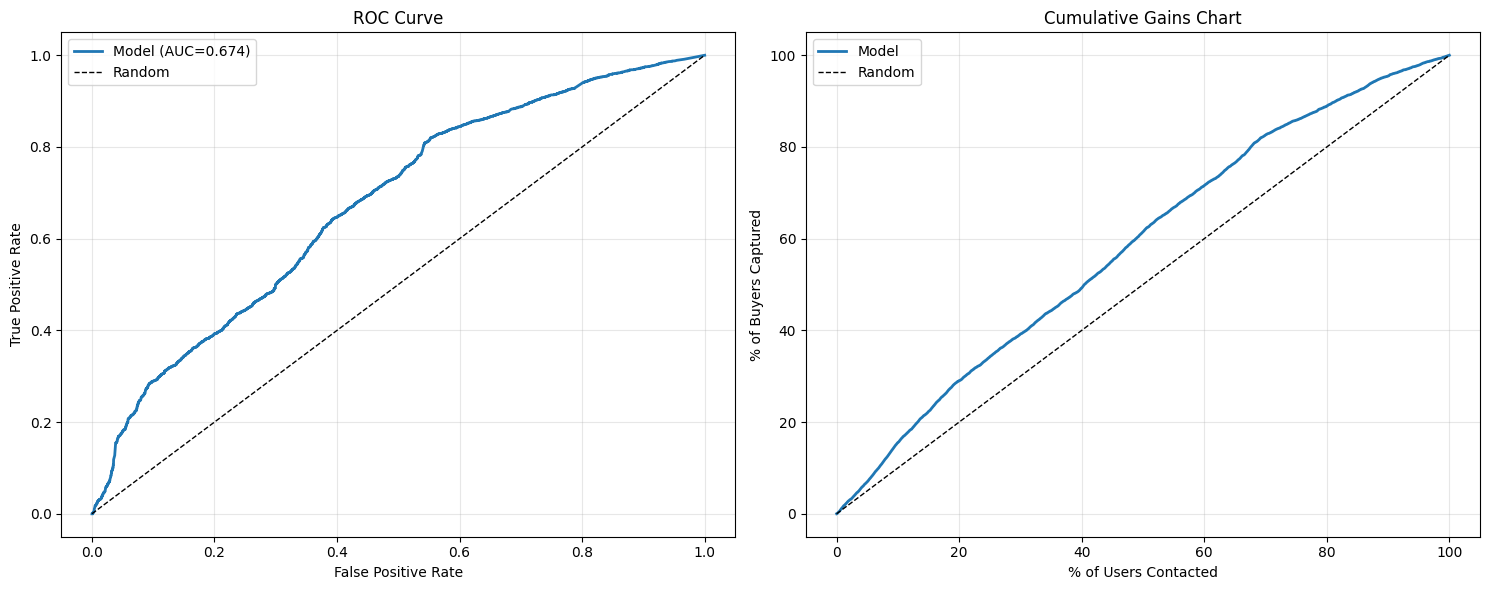

In [103]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns


class ModelEvaluator:
    """
    Complete evaluator for purchase propensity models.
    """

    def __init__(self, y_true, y_pred_proba, campaign_cost_per_user=1.0, revenue_per_purchase=20.0):
        """
        Parameters:
        -----------
        y_true : array, true labels (0 or 1)
        y_pred_proba : array, predicted probabilities (0 to 1)
        campaign_cost_per_user : float, cost of contacting one user
        revenue_per_purchase : float, expected revenue per purchase
        """
        self.y_true = np.array(y_true)
        self.y_pred_proba = np.array(y_pred_proba)
        self.campaign_cost = campaign_cost_per_user
        self.revenue = revenue_per_purchase

    def evaluate_all(self):
        """Complete model evaluation."""
        print("="*60)
        print("MODEL EVALUATION REPORT")
        print("="*60)

        # 1. General metrics
        print("\n1. GENERAL METRICS")
        print("-" * 60)
        self.general_metrics()

        # 2. Metrics by threshold
        print("\n2. METRICS AT DIFFERENT THRESHOLDS")
        print("-" * 60)
        self.metrics_by_threshold()

        # 3. Top-K analysis
        print("\n3. TOP-K ANALYSIS (Campaign Targeting)")
        print("-" * 60)
        self.top_k_analysis()

        # 4. Business impact
        print("\n4. BUSINESS IMPACT ANALYSIS")
        print("-" * 60)
        self.business_impact()

        # 5. Plots
        print("\n5. GENERATING PLOTS...")
        print("-" * 60)
        self.plot_all()

    def general_metrics(self):
        """General metrics independent of threshold."""
        # AUC-ROC
        auc_roc = roc_auc_score(self.y_true, self.y_pred_proba)
        print(f"AUC-ROC: {auc_roc:.4f}")

        # AUC-PR (better for imbalanced datasets)
        auc_pr = average_precision_score(self.y_true, self.y_pred_proba)
        print(f"AUC-PR (Average Precision): {auc_pr:.4f}")

        # Baseline (random model)
        baseline = self.y_true.mean()
        print(f"Baseline (% positives): {baseline:.2%}")

        # Lift over baseline
        print(f"Lift over random: {auc_roc / 0.5:.2f}x")

    def metrics_by_threshold(self, thresholds=[0.3, 0.5, 0.7]):
        """Metrics at different decision thresholds."""
        results = []

        for threshold in thresholds:
            y_pred = (self.y_pred_proba >= threshold).astype(int)

            tn, fp, fn, tp = confusion_matrix(self.y_true, y_pred).ravel()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            results.append({
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'tp': tp,
                'fp': fp,
                'fn': fn,
                'tn': tn
            })

        df_results = pd.DataFrame(results)
        print(df_results.to_string(index=False))

        return df_results

    def top_k_analysis(self, k_values=[0.05, 0.10, 0.20, 0.30]):
        """
        Top-K analysis: if we contact the top K% predicted users,
        how well do we perform?

        Very useful for budget-limited campaigns.
        """
        results = []
        n = len(self.y_true)

        # Sort by predicted probability (descending)
        sorted_indices = np.argsort(self.y_pred_proba)[::-1]
        y_true_sorted = self.y_true[sorted_indices]

        for k_pct in k_values:
            k_size = int(n * k_pct)
            if k_size == 0:
                continue

            # Top K users
            top_k_actual = y_true_sorted[:k_size]

            # Metrics
            tp = top_k_actual.sum()  # Captured buyers
            total_positives = self.y_true.sum()  # Total buyers

            precision_at_k = tp / k_size
            recall_at_k = tp / total_positives if total_positives > 0 else 0

            # Lift: how much better than random
            random_capture = k_pct  # If we selected randomly
            lift = precision_at_k / self.y_true.mean() if self.y_true.mean() > 0 else 0

            results.append({
                'top_%': f"{k_pct*100:.0f}%",
                'n_users': k_size,
                'buyers_captured': tp,
                'precision@k': precision_at_k,
                'recall@k': recall_at_k,
                'lift': lift
            })

        df_results = pd.DataFrame(results)
        print(df_results.to_string(index=False))

        return df_results

    def business_impact(self, k_values=[0.10, 0.20, 0.30]):
        """
        Economic impact of using the model vs alternative strategies.
        """
        n = len(self.y_true)
        total_buyers = self.y_true.sum()

        print(f"Total users: {n:,}")
        print(f"Total buyers: {total_buyers:,} ({total_buyers/n:.2%})")
        print(f"Campaign cost per user: ${self.campaign_cost:.2f}")
        print(f"Revenue per purchase: ${self.revenue:.2f}")
        print()

        # Strategy 1: Contact everyone
        print("Strategy 1: CONTACT EVERYONE")
        cost_all = n * self.campaign_cost
        revenue_all = total_buyers * self.revenue
        profit_all = revenue_all - cost_all
        roi_all = (profit_all / cost_all * 100) if cost_all > 0 else 0

        print(f"  Cost: ${cost_all:,.2f}")
        print(f"  Revenue: ${revenue_all:,.2f}")
        print(f"  Profit: ${profit_all:,.2f}")
        print(f"  ROI: {roi_all:.1f}%")
        print()

        # Strategy 2: Model-based targeting (top-K)
        sorted_indices = np.argsort(self.y_pred_proba)[::-1]
        y_true_sorted = self.y_true[sorted_indices]

        for k_pct in k_values:
            k_size = int(n * k_pct)
            if k_size == 0:
                continue

            top_k_buyers = y_true_sorted[:k_size].sum()

            cost_model = k_size * self.campaign_cost
            revenue_model = top_k_buyers * self.revenue
            profit_model = revenue_model - cost_model
            roi_model = (profit_model / cost_model * 100) if cost_model > 0 else 0

            # Comparison
            profit_increase = profit_model - profit_all
            profit_increase_pct = (profit_increase / abs(profit_all) * 100) if profit_all != 0 else 0

            print(f"Strategy 2: MODEL-BASED (Top {k_pct*100:.0f}%)")
            print(f"  Users contacted: {k_size:,} ({k_pct*100:.0f}% of total)")
            print(f"  Buyers captured: {top_k_buyers:,} ({top_k_buyers/total_buyers*100:.1f}% of all buyers)")
            print(f"  Cost: ${cost_model:,.2f}")
            print(f"  Revenue: ${revenue_model:,.2f}")
            print(f"  Profit: ${profit_model:,.2f}")
            print(f"  ROI: {roi_model:.1f}%")
            print(f"  Profit vs contact all: ${profit_increase:+,.2f} ({profit_increase_pct:+.1f}%)")
            print()

    def plot_all(self):
        """Generates all important plots."""
        """Generates all important plots (ROC and Cumulative Gains)."""
        # Adjusted to 1 row, 2 columns for a cleaner look
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # 1. ROC Curve
        fpr, tpr, _ = roc_curve(self.y_true, self.y_pred_proba)
        auc_roc = roc_auc_score(self.y_true, self.y_pred_proba)

        axes[0].plot(fpr, tpr, label=f'Model (AUC={auc_roc:.3f})', linewidth=2)
        axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC Curve')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # 2. Cumulative Gains Chart
        sorted_indices = np.argsort(self.y_pred_proba)[::-1]
        y_true_sorted = self.y_true[sorted_indices]
        cumulative_gains = np.cumsum(y_true_sorted) / self.y_true.sum()
        percentage_contacted = np.arange(1, len(y_true_sorted) + 1) / len(y_true_sorted)

        axes[1].plot(percentage_contacted * 100, cumulative_gains * 100,
                      label='Model', linewidth=2)
        axes[1].plot([0, 100], [0, 100], 'k--', label='Random', linewidth=1)
        axes[1].set_xlabel('% of Users Contacted')
        axes[1].set_ylabel('% of Buyers Captured')
        axes[1].set_title('Cumulative Gains Chart')
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
        print("Plot saved as 'model_evaluation.png'")
        plt.show()

        return fig



def evaluate_model(model, X_test, y_test, campaign_cost=8.0, revenue_per_sale=10.0):
    """
    Wrapper function to evaluate a trained model.
    """
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Create evaluator
    evaluator = ModelEvaluator(
        y_true=y_test,
        y_pred_proba=y_pred_proba,
        campaign_cost_per_user=campaign_cost,
        revenue_per_purchase=revenue_per_sale
    )

    # Evaluate
    evaluator.evaluate_all()

    return evaluator


# Use like this:
evaluator = evaluate_model(
    model=model,
    X_test=X_test,
    y_test=y_test,
    campaign_cost=8.0,      # Cost to contact each user
    revenue_per_sale=20.0   # Expected revenue per purchase
)

**How I defined the labels**

I used a binary classification approach where the target is encoded as 1 for users who either completed a purchase or a gift_send action within the observation window, and 0 for users who did not.

The model also outputs predict_proba, which represents the probability of a user belonging to class 1.

**Top features and why I chose them**

The top features selected for the model were:

- opened_30d
- frequency_score
- purchased_7d
- purchased_30d
- have_cart
- avg_days_between_purchases
- recency_score
- engagement_score
- days_since_last_purchase

These features were chosen based on their correlation with the target variable (purchase), followed by iterative experimentation during model development.

**Metric used and why accuracy was not used**

Accuracy was not used as the primary metric because it can be misleading in cases of class imbalance and does not reflect the model’s ability to correctly identify positive cases effectively. In this context, identifying true positives (users who will purchase or send a gift) is more important than overall classification correctness.

AUC-PR was preferred because it provides a more informative evaluation of model performance on the positive class

## Part 2 - Recomendation

### **Important**

I decided to use an algorithmic approach to define product recommendations because of the size of the dataset and time constraints. However, I would like to experiment with creating a small RAG system by embedding the text, generating more context with LLMs, and then using cosine similarity. The RAG approach would be more like the first exercise of last week (gesture-SSE-assessment).

This would be more like when you return to your Amazon home page that shows products from similar categories rather than products from a similar area. That makes sense to me because of the small size of the dataset (<31 products).

In [104]:
X=features_df[[
 'opened_30d',
 'frequency_score',
 'purchased_7d',
 'purchased_30d',
 'have_cart',
 'avg_days_between_purchases',
 'recency_score',
 'engagement_score',
 'days_since_last_purchase']]
predict = model.predict_proba(X)[:, 1]

In [105]:
results = pd.DataFrame({
    "user_id": features_df["user_id"],
    "probability": predict
})

In [106]:
results = (
    results
    .sort_values(by="probability", ascending=False)
    .drop_duplicates(subset="user_id", keep="first")
)

top_20_user_ids = results.head(20)

In [107]:
df_filtered = df[df["user_id"].isin(top_20_user_ids["user_id"])]

In [108]:
df_filtered["user_id"].unique()

array(['usr_0285', 'usr_0568', 'usr_0408', 'usr_0430', 'usr_0684',
       'usr_0521', 'usr_0695', 'usr_0106', 'usr_0088', 'usr_0623',
       'usr_0284', 'usr_0108', 'usr_0789', 'usr_0769', 'usr_0727',
       'usr_0330', 'usr_0634', 'usr_0080', 'usr_0619', 'usr_0764'],
      dtype=object)

In [109]:
sku_counts = (
    df_filtered.groupby(["user_id", "sku_id"])
      .size()
      .reset_index(name="count")
)
sku_counts = sku_counts.sort_values(
    by=["user_id", "count"],
    ascending=[True, False]
)
top5_skus_per_user = (
    sku_counts.groupby("user_id")
              .head(5)
              .reset_index(drop=True)
)
top5_dict = (
    top5_skus_per_user.groupby("user_id")["sku_id"]
    .apply(list)
    .to_dict()
)

In [110]:
top5_dict

{'usr_0080': ['SKU008'],
 'usr_0088': ['SKU028', 'SKU016'],
 'usr_0106': ['SKU030'],
 'usr_0108': ['SKU009', 'SKU005', 'SKU028', 'SKU002', 'SKU019'],
 'usr_0284': ['SKU004', 'SKU008'],
 'usr_0285': ['SKU006'],
 'usr_0330': ['SKU018', 'SKU001', 'SKU011', 'SKU015', 'SKU022'],
 'usr_0408': ['SKU004', 'SKU019', 'SKU030'],
 'usr_0430': ['SKU030', 'SKU014', 'SKU023', 'SKU019', 'SKU008'],
 'usr_0521': ['SKU027', 'SKU001', 'SKU006'],
 'usr_0568': ['SKU012', 'SKU026', 'SKU027', 'SKU017', 'SKU011'],
 'usr_0619': ['SKU003'],
 'usr_0623': ['SKU001'],
 'usr_0634': ['SKU030', 'SKU001', 'SKU019'],
 'usr_0684': ['SKU018', 'SKU007'],
 'usr_0695': ['SKU003', 'SKU020', 'SKU014', 'SKU023'],
 'usr_0727': ['SKU002', 'SKU022', 'SKU021', 'SKU005', 'SKU009'],
 'usr_0764': ['SKU001'],
 'usr_0769': ['SKU010', 'SKU029'],
 'usr_0789': ['SKU003', 'SKU013', 'SKU026']}

In [111]:
import random

sku_to_category = dict(zip(df_products["sku_id"], df_products["category"]))
all_skus = set(df_products["sku_id"])

# group SKUs by category
category_to_skus = df_products.groupby("category")["sku_id"].apply(list).to_dict()

def fill_recommendations(seed_skus, df, target=5):
    seed_skus = list(seed_skus)
    selected = []
    used = set(seed_skus)  # Remove products that the client purchased

    # category based expansion
    for sku in seed_skus:
        if len(selected) >= target:
            break
        if sku not in used and sku in all_skus:
            selected.append(sku)
            used.add(sku)

        # get category and pull similar items
        if sku in sku_to_category:
            cat = sku_to_category[sku]
            candidates = category_to_skus.get(cat, [])

            for c in candidates:
                if len(selected) >= target:
                    break
                if c not in used:
                    selected.append(c)
                    used.add(c)

    # If you don't have more categories, fill remaining slots with random products
    remaining = list(all_skus - used)
    random.shuffle(remaining)

    while len(selected) < target and remaining:
        selected.append(remaining.pop())

    return selected[:target]

In [112]:
result = {
    user: fill_recommendations(skus, df, target=5)
    for user, skus in top5_dict.items()
}

result

{'usr_0080': ['SKU014', 'SKU023', 'SKU015', 'SKU024', 'SKU018'],
 'usr_0088': ['SKU002', 'SKU005', 'SKU009', 'SKU021', 'SKU024'],
 'usr_0106': ['SKU019', 'SKU010', 'SKU024', 'SKU002', 'SKU022'],
 'usr_0108': ['SKU016', 'SKU021', 'SKU024', 'SKU030', 'SKU013'],
 'usr_0284': ['SKU014', 'SKU023', 'SKU029', 'SKU006', 'SKU001'],
 'usr_0285': ['SKU025', 'SKU030', 'SKU012', 'SKU014', 'SKU028'],
 'usr_0330': ['SKU003', 'SKU007', 'SKU013', 'SKU026', 'SKU005'],
 'usr_0408': ['SKU005', 'SKU023', 'SKU025', 'SKU006', 'SKU029'],
 'usr_0430': ['SKU029', 'SKU009', 'SKU010', 'SKU015', 'SKU001'],
 'usr_0521': ['SKU020', 'SKU025', 'SKU015', 'SKU021', 'SKU014'],
 'usr_0568': ['SKU013', 'SKU015', 'SKU022', 'SKU020', 'SKU004'],
 'usr_0619': ['SKU007', 'SKU018', 'SKU010', 'SKU013', 'SKU015'],
 'usr_0623': ['SKU027', 'SKU016', 'SKU010', 'SKU018', 'SKU008'],
 'usr_0634': ['SKU017', 'SKU021', 'SKU025', 'SKU010', 'SKU005'],
 'usr_0684': ['SKU003', 'SKU028', 'SKU014', 'SKU012', 'SKU005'],
 'usr_0695': ['SKU007', '

In [113]:
rows = []

for user_id, skus in result.items():  # or top5_dict if you prefer original
    for rank, sku in enumerate(skus, start=1):
        rows.append({
            "user_id": user_id,
            "sku_id": sku,
            "rank": rank
        })

df_out = pd.DataFrame(rows)
df_out

,user_id,sku_id,rank
0,usr_0080,SKU014,1
1,usr_0080,SKU023,2
2,usr_0080,SKU015,3
3,usr_0080,SKU024,4
4,usr_0080,SKU018,5
...,...,...,...
95,usr_0789,SKU007,1
96,usr_0789,SKU018,2
97,usr_0789,SKU011,3
98,usr_0789,SKU015,4


## Part 3 - Degradetion

**If this system went live tomorrow, what are the top 3 things most likely to break or degrade silently — and how would you catch each one?**

### 1. Conversion Rate of the Campaign
Track business-level metrics to detect model degradation in real-world performance.

Establish a baseline conversion rate using initial campaign data.
Continuously monitor performance; if conversion drops outside the expected range, investigate potential causes.

### 2. Data Drift / Feature Drift

Monitor for changes in the distribution of input features and model performance over time.

Generate a regularly updated evaluation dataset.
Track performance metrics such as AUC on a weekly or monthly basis.
Define a threshold for acceptable drift; if exceeded, trigger model retraining.

### 3. Pipeline / Feature Engineering Bugs
Ensure that changes in upstream systems or data pipelines do not silently corrupt inputs.
Set up alerts for anomalies such as sudden drops in key features or missing data.

